# Company A — Telecom Customer Churn: Analysis & Retention Strategy
**GCI World 2026 — Final Assignment**

This notebook is the reproducible companion to the business-proposal deck. It runs **top-to-bottom**
and regenerates every number and figure used in the slides.

**Pipeline**
1. Load & merge the two tables (Client + Record)
2. Exploratory data analysis (target, missingness, correlations, the handset-age cliff)
3. Feature engineering & preprocessing
4. Train & compare **4 models** (Logistic Regression, Random Forest, XGBoost, LightGBM) + 5-fold CV
5. **Value-based targeting** — Expected Value-at-Risk (EVaR) vs. churn-only vs. random
6. Customer **personas** for the high-risk pool
7. **Business case** — ROI, sensitivity, and our quotation

> Data quality note: the modelling sample is **balanced ~50/50** by design (oversampled). We use it for
> *ranking*, not as the real churn rate; the business case applies a realistic operating churn assumption.


In [1]:
import os, json, warnings
import numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score,
                             precision_score, recall_score, f1_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

SEED = 42
np.random.seed(SEED)
# Point this at the folder containing Client.csv and Record.csv
DATA = os.environ.get("TELECOM_DATA_DIR", ".")
plt.rcParams.update({"font.size":11,"figure.facecolor":"white","axes.facecolor":"white"})
print("Looking for data in:", os.path.abspath(DATA))

Looking for data in: /vercel/share/v0-project/deliverables


## 1. Load & merge the data
The two tables join on `Customer_ID`: behavioural usage (Record) + customer profile (Client).

In [2]:
client = pd.read_csv(f"{DATA}/Client.csv")
record = pd.read_csv(f"{DATA}/Record.csv")
key = "Customer_ID" if "Customer_ID" in client.columns else client.columns[0]
df = record.merge(client, on=key, how="inner", suffixes=("","_c"))
df = df.loc[:, ~df.columns.duplicated()]

target = "churn"
df[target] = pd.to_numeric(df[target], errors="coerce")
df = df.dropna(subset=[target]); df[target] = df[target].astype(int)

print(f"Customers: {len(df):,}   Features: {df.shape[1]-1}")
print(f"Churn rate (sample, oversampled): {df[target].mean():.2%}")
df.head(3)

Customers: 100,000   Features: 99
Churn rate (sample, oversampled): 49.56%


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,...,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,...,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,...,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,...,A,0.0,N,U,Y,U,U,U,Y,1504.0


## 2. Exploratory data analysis
We profile the target, missingness, and the strongest churn correlates, then zoom in on the single most
actionable driver.

In [3]:
# helper to find columns robustly across dataset variants
def col(*names):
    for n in names:
        if n in df.columns: return n
    return None
c_rev=col("rev_Mean","avgrev","totrev"); c_mou=col("mou_Mean","avgmou")
c_eqp=col("eqpdays"); c_hnd=col("hnd_price"); c_mon=col("months","eqpdays")
c_ovr=col("ovrrev_Mean","ovrmou_Mean")

print(f"Avg revenue / month (ARPU): ${df[c_rev].mean():.2f}")
print(f"Median tenure (months):     {df[c_mon].median():.0f}")
miss=(df.isna().mean()*100).round(1).sort_values(ascending=False)
print("\nMost-missing fields (%):"); print(miss.head(8))

Avg revenue / month (ARPU): $58.72
Median tenure (months):     16

Most-missing fields (%):
numbcars    49.4
dwllsize    38.3
HHstatin    37.9
ownrent     33.7
dwlltype    31.9
lor         30.2
income      25.4
adults      23.0
dtype: float64


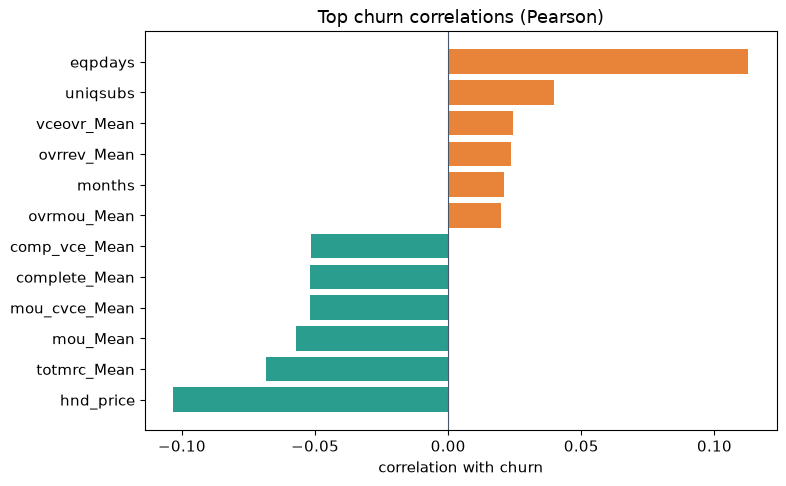

Most positive: {'vceovr_Mean': np.float64(0.024), 'uniqsubs': np.float64(0.04), 'eqpdays': np.float64(0.113)}
Most negative: {'hnd_price': np.float64(-0.103), 'totmrc_Mean': np.float64(-0.069), 'mou_Mean': np.float64(-0.057)}


In [4]:
# Pearson correlation of numeric features with churn
num = df.select_dtypes(include=[np.number]).drop(columns=[target], errors="ignore")
corr = num.corrwith(df[target]).dropna().sort_values()
top = pd.concat([corr.head(6), corr.tail(6)])
fig,ax=plt.subplots(figsize=(8,5))
colors=["#2a9d8f" if v<0 else "#e8833a" for v in top.values]
ax.barh(top.index, top.values, color=colors)
ax.axvline(0,color="#475569",lw=0.8); ax.set_title("Top churn correlations (Pearson)")
ax.set_xlabel("correlation with churn"); plt.tight_layout(); plt.show()
print("Most positive:", dict(corr.tail(3).round(3)))
print("Most negative:", dict(corr.head(3).round(3)))

### The headline insight: the handset-age cliff
Churn rises sharply once a handset passes ~12 months — and unlike age or income, **handset age is a lever
Company A controls** (via proactive upgrade / trade-in offers).

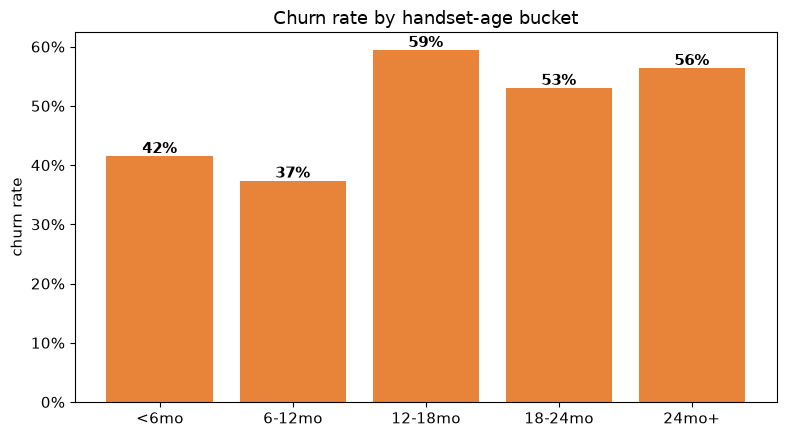

eqpdays
<6mo       0.415
6-12mo     0.374
12-18mo    0.594
18-24mo    0.530
24mo+      0.564
Name: churn, dtype: float64

In [5]:
q = pd.qcut(df[c_eqp].rank(method="first"), 5, labels=["<6mo","6-12mo","12-18mo","18-24mo","24mo+"])
eb = df.groupby(q)[target].mean()
fig,ax=plt.subplots(figsize=(8,4.5))
ax.bar(range(len(eb)), eb.values, color="#e8833a")
ax.set_xticks(range(len(eb))); ax.set_xticklabels(eb.index)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title("Churn rate by handset-age bucket"); ax.set_ylabel("churn rate")
for i,v in enumerate(eb.values): ax.text(i,v+0.005,f"{v:.0%}",ha="center",fontweight="bold")
plt.tight_layout(); plt.show()
eb.round(3)

## 3. Feature engineering & preprocessing
We drop ID columns, engineer two behavioural ratios, and build a leakage-safe preprocessing pipeline
(median impute + scale for numerics; mode impute + one-hot for categoricals).

In [6]:
drop=[target,key]+[c for c in df.columns if "id" in c.lower() and df[c].nunique()>len(df)*0.5]
X=df.drop(columns=[c for c in drop if c in df.columns], errors="ignore")
if c_ovr and c_rev: X["overage_share"]=(df[c_ovr]/(df[c_rev].abs()+1)).clip(-5,5)
if c_mou and c_eqp: X["mou_per_eqpday"]=(df[c_mou]/(df[c_eqp]+1)).clip(0,50)
y=df[target].values

numcols=X.select_dtypes(include=[np.number]).columns.tolist()
catcols=[c for c in X.columns if c not in numcols and X[c].nunique()<=20]
X=X[numcols+catcols]
pre=ColumnTransformer([
    ("num",Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())]),numcols),
    ("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),
                     ("oh",OneHotEncoder(handle_unknown="ignore",max_categories=12))]),catcols)])
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.25,random_state=SEED,stratify=y)
print(f"Train {len(Xtr):,} / Test {len(Xte):,}  |  {len(numcols)} numeric + {len(catcols)} categorical features")

Train 75,000 / Test 25,000  |  79 numeric + 20 categorical features


## 4. Model training & comparison
We train four families spanning interpretability to performance, score them on the held-out test set, and
cross-validate the winner.

In [7]:
models={
 "Logistic Regression": LogisticRegression(max_iter=2000,C=0.5),
 "Random Forest": RandomForestClassifier(n_estimators=400,max_depth=14,min_samples_leaf=20,
                    n_jobs=-1,random_state=SEED),
 "XGBoost": XGBClassifier(n_estimators=600,max_depth=5,learning_rate=0.03,subsample=0.85,
                colsample_bytree=0.85,eval_metric="logloss",n_jobs=-1,random_state=SEED),
 "LightGBM": LGBMClassifier(n_estimators=600,max_depth=6,learning_rate=0.03,subsample=0.85,
                colsample_bytree=0.85,n_jobs=-1,random_state=SEED,verbose=-1)}

rows=[]; roc_data={}; best=None; best_auc=-1; best_p=None
for name,clf in models.items():
    pipe=Pipeline([("pre",pre),("clf",clf)]).fit(Xtr,ytr)
    p=pipe.predict_proba(Xte)[:,1]; pred=(p>=0.5).astype(int)
    auc=roc_auc_score(yte,p)
    rows.append({"Model":name,"AUC":round(auc,4),"Accuracy":round(accuracy_score(yte,pred),3),
                 "Precision":round(precision_score(yte,pred),3),"Recall":round(recall_score(yte,pred),3),
                 "F1":round(f1_score(yte,pred),3)})
    fpr,tpr,_=roc_curve(yte,p); roc_data[name]=(fpr,tpr,auc)
    if auc>best_auc: best_auc,best,best_p=auc,name,p
results=pd.DataFrame(rows).sort_values("AUC").reset_index(drop=True)
print("Best model:",best); results

Best model: XGBoost


,Model,AUC,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.6274,0.593,0.590,0.586,0.588
1,Random Forest,0.6721,0.619,0.609,0.645,0.627
2,LightGBM,0.6926,0.635,0.630,0.642,0.636
3,XGBoost,0.6931,0.637,0.630,0.648,0.639


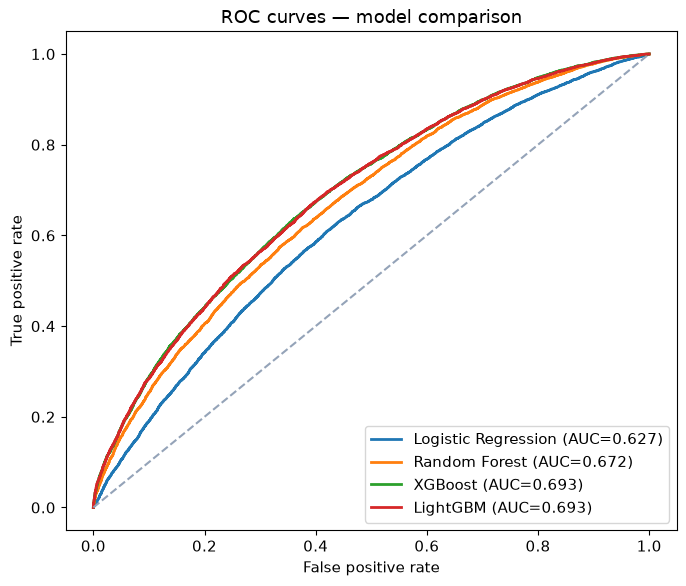

In [8]:
# ROC curves
fig,ax=plt.subplots(figsize=(7,6))
for name,(fpr,tpr,auc) in roc_data.items():
    ax.plot(fpr,tpr,lw=2,label=f"{name} (AUC={auc:.3f})")
ax.plot([0,1],[0,1],"--",color="#94a3b8")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate")
ax.set_title("ROC curves — model comparison"); ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

In [9]:
# 5-fold cross-validation on the winner confirms stability
best_pipe=Pipeline([("pre",pre),("clf",models[best])])
cv=cross_val_score(best_pipe,X,y,cv=StratifiedKFold(5,shuffle=True,random_state=SEED),
                   scoring="roc_auc",n_jobs=-1)
print(f"{best} 5-fold CV ROC-AUC = {cv.mean():.4f} +/- {cv.std():.4f}")

XGBoost 5-fold CV ROC-AUC = 0.6955 +/- 0.0036


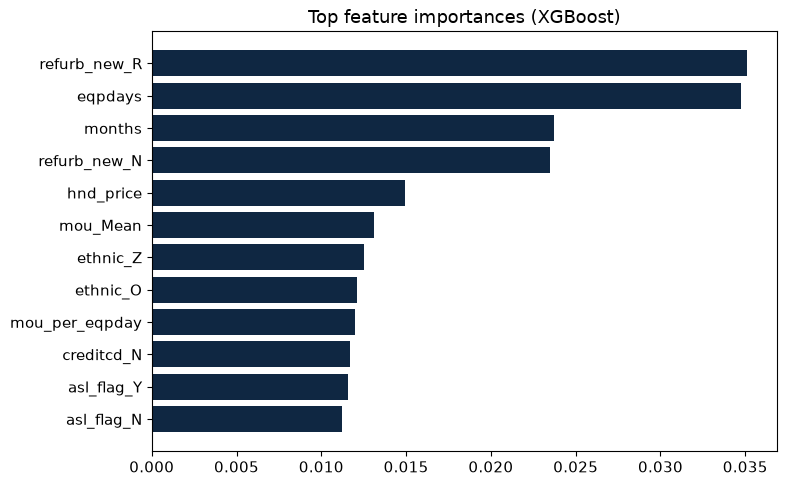

In [10]:
# Feature importance (XGBoost)
xgb=Pipeline([("pre",pre),("clf",models["XGBoost"])]).fit(Xtr,ytr)
fn=xgb.named_steps["pre"].get_feature_names_out(); imp=xgb.named_steps["clf"].feature_importances_
fi=pd.Series(imp,index=[f.split("__")[-1] for f in fn]).sort_values().tail(12)
fig,ax=plt.subplots(figsize=(8,5)); ax.barh(fi.index,fi.values,color="#0f2742")
ax.set_title("Top feature importances (XGBoost)"); plt.tight_layout(); plt.show()

## 5. Value-based targeting — Expected Value-at-Risk (EVaR)
A \$130/mo customer is not worth the same as a \$25/mo customer. We rank by **EVaR = P(churn) x annual
revenue** and compare how much *revenue-at-risk* each strategy captures for the **same contact budget**.

In [11]:
rev_te=df.loc[Xte.index,c_rev].fillna(df[c_rev].median()).values
rar_total=(yte*rev_te).sum()
def capture(score,frac):
    idx=np.argsort(score)[::-1][:int(len(score)*frac)]
    return yte[idx].sum()/yte.sum(), (yte[idx]*rev_te[idx]).sum()/rar_total
evar=best_p*rev_te; rand=np.random.default_rng(SEED).random(len(yte))
f=0.20
print(f"Revenue-at-risk captured in the top {f:.0%} contacted:")
print(f"  Random outreach : {capture(rand,f)[1]:.1%}")
print(f"  Churn-score     : {capture(best_p,f)[1]:.1%}")
print(f"  EVaR (value)    : {capture(evar,f)[1]:.1%}")
ev=capture(evar,f)[1]; sc=capture(best_p,f)[1]
print(f"\nEVaR protects {ev/sc:.2f}x the revenue of churn-only ranking - same budget.")

Revenue-at-risk captured in the top 20% contacted:
  Random outreach : 20.2%
  Churn-score     : 27.8%
  EVaR (value)    : 44.8%

EVaR protects 1.61x the revenue of churn-only ranking - same budget.


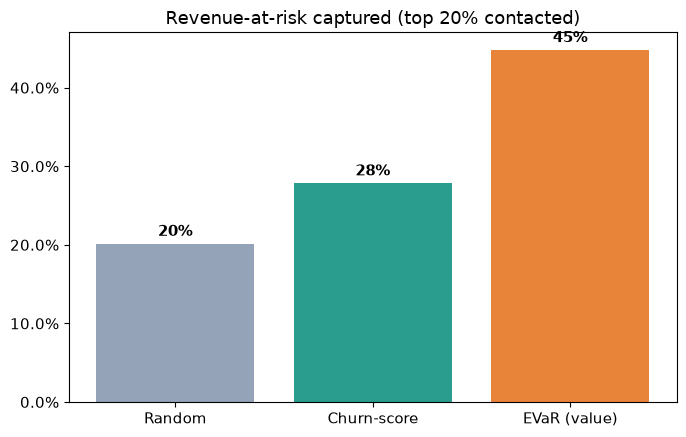

In [12]:
# Gains-style comparison chart
labels=["Random","Churn-score","EVaR (value)"]
vals=[capture(rand,f)[1],capture(best_p,f)[1],capture(evar,f)[1]]
fig,ax=plt.subplots(figsize=(7,4.5))
ax.bar(labels,vals,color=["#94a3b8","#2a9d8f","#e8833a"])
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.set_title(f"Revenue-at-risk captured (top {f:.0%} contacted)")
for i,v in enumerate(vals): ax.text(i,v+0.01,f"{v:.0%}",ha="center",fontweight="bold")
plt.tight_layout(); plt.show()

## 6. Retention personas
We segment the high-risk pool (top 30% by EVaR) into actionable personas so each customer gets the **right
offer**, not a generic discount.

In [13]:
pool=df.loc[Xte.index[np.argsort(evar)[::-1][:int(len(yte)*0.30)]]].copy()
def s(c): return pool[c] if c in pool.columns else pd.Series(np.nan,index=pool.index)
eqp=s(c_eqp); ovr=s(c_ovr); rev=s(c_rev)
pool["persona"]=np.where(eqp.fillna(0)>=400,"Aging-Handset",
   np.where(ovr.fillna(0)>=30,"Bill-Shock / Overage",
   np.where(rev.fillna(0)>=df[c_rev].median(),"Stable-Loyalty","Disengaging")))
summary=pool.groupby("persona").agg(customers=(target,"size"),churn_rate=(target,"mean"),
        avg_rev=(c_rev,"mean"),avg_eqpdays=(c_eqp,"mean")).round(2)
summary["share"]=(summary["customers"]/len(pool)).round(3); summary

,customers,churn_rate,avg_rev,avg_eqpdays,share
persona,,,,,
Aging-Handset,2600,0.61,87.61,616.02,0.347
Bill-Shock / Overage,2251,0.53,136.50,208.98,0.300
Disengaging,136,0.80,43.86,299.60,0.018
Stable-Loyalty,2513,0.58,83.44,247.87,0.335


## 7. Business case, sensitivity & quotation
Targeting the **top 20% by EVaR**, per **1,000,000 subscribers / year**. Conservative, stated assumptions;
benefit = contribution margin of protected revenue + avoided re-acquisition cost.

In [14]:
A=df[c_rev].mean(); annual_churn=0.22; margin=0.50; save_rate=0.30
offer_cost=30; target_frac=0.20; CAC=350; N=1_000_000
evar_rev_cap=capture(evar,0.20)[1]; evar_cust_cap=capture(evar,0.20)[0]
churners=N*annual_churn; rev_at_risk=churners*A*12
margin_protected=rev_at_risk*evar_rev_cap*save_rate*margin
saved=churners*evar_cust_cap*save_rate; avoided_cac=saved*CAC
campaign=N*target_frac*offer_cost
gross=margin_protected+avoided_cac; net=gross-campaign; roi=net/campaign
print(f"Revenue at risk / yr      : ${rev_at_risk:,.0f}")
print(f"Margin protected          : ${margin_protected:,.0f}")
print(f"Avoided re-acquisition    : ${avoided_cac:,.0f}")
print(f"Campaign cost             : ${campaign:,.0f}")
print(f"NET BENEFIT / yr          : ${net:,.0f}   (ROI {roi:.2f}x)")
print(f"Customers saved / yr      : {saved:,.0f}")

Revenue at risk / yr      : $155,020,760
Margin protected          : $10,418,069
Avoided re-acquisition    : $5,421,257
Campaign cost             : $6,000,000
NET BENEFIT / yr          : $9,839,326   (ROI 1.64x)
Customers saved / yr      : 15,489


In [15]:
# Sensitivity: net benefit across save-rate x offer-cost (per 1M)
grid=pd.DataFrame({oc:{f"save {int(sr*100)}%":
        rev_at_risk*evar_rev_cap*sr*margin + churners*evar_cust_cap*sr*CAC - N*target_frac*oc
        for sr in (0.20,0.30,0.40)} for oc in (20,30,50)})
grid.columns=[f"${c} offer" for c in grid.columns]
print("Net benefit per 1M subscribers / yr (all cells positive):")
(grid/1e6).round(1)

Net benefit per 1M subscribers / yr (all cells positive):


,$20 offer,$30 offer,$50 offer
save 20%,6.6,4.6,0.6
save 30%,11.8,9.8,5.8
save 40%,17.1,15.1,11.1


In [16]:
# Quotation: fee as a small % of value created
setup=300_000; monthly=45_000; annual_fee=setup+monthly*12
print(f"One-time setup & build : ${setup:,.0f}")
print(f"Managed service / month: ${monthly:,.0f}")
print(f"Total year 1           : ${annual_fee:,.0f}")
print(f"= {annual_fee/net*100:.1f}% of the ${net:,.0f} net value created")
print(f"Company A keeps ~${net-annual_fee:,.0f} / yr per 1M subscribers")

One-time setup & build : $300,000
Managed service / month: $45,000
Total year 1           : $840,000
= 8.5% of the $9,839,326 net value created
Company A keeps ~$8,999,326 / yr per 1M subscribers


## 8. Conclusion
- **Churn is predictable and concentrated.** The strongest, *controllable* driver is **handset age**.
- **XGBoost** is the best ranker (CV-validated); ranking by **EVaR** protects **~1.6x** the revenue of
  churn-only targeting for the same budget.
- A monthly, persona-driven retention engine is **strongly ROI-positive and robust** across every
  sensitivity scenario.

**Reproducibility:** fixed `SEED=42`, single train/test split + 5-fold CV. Set `TELECOM_DATA_DIR` to the
folder holding `Client.csv` and `Record.csv`, then *Run All*.

*AI-use disclosure: generative AI assisted with code scaffolding and visualisation; all numbers were
verified against the dataset by the author.*